# Norway Future skills - Data Quality and Labor Market Overview

## objective

Undrestand the quality and structure of the Norwegian job posting dataset before deeper skill analysis.

## Dataset Source

This notebook uses the processed dataset generated by:
- src/collect_nav_jobs.py
- src/clean_jobs.py

The raw data is collected from NAV Arbeidsplassen API and cleaned before analysis.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/jobs_clean.csv")

print("What does the Norwegian job market look like?")

df.head()

What does the Norwegian job market look like?


,job_id,title,company,published,expires,city,occupation,category,skills,has_city,has_occupation,has_skills
0,0112ac82-d16e-449b-8ae0-17e5bb874829,Vil du være med å styrke vår informasjonsforva...,"Informasjonsforvaltning, Lørenskog kommune",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,LØRENSKOG,Not classified,Not classified,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",True,False,True
1,050bb19a-a9a0-406d-8902-7f211502cd63,Nattsykepleier,"Skien Helsehus, Skien kommune",2026-08-03T00:00:00+02:00,2026-08-31T00:00:00+02:00,SKIEN,Not classified,"Sykepleier, Sykepleier, Sykepleiere","Helsehus, Kommunal helse, Korttidsopphold, Med...",True,False,True
2,0af40df5-b09f-46fb-b6a6-37f943aee756,Nyetablert oppfølgingsteam for barn/familier s...,BUPA Drammen,2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,DRAMMEN,Not classified,"Psykologspesialist, Psykologspesialist, Psykol...","Ambulant arbeid, Barn, Barne- og ungdomspsykol...",True,False,True
3,0bc718d8-c7ea-4eb0-a9f5-efa112642bd5,Overlege,"Klinikk psykisk helse og avhengighet, BUP Oslo...",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,OSLO,Not classified,"Overlege, Overlege, Legespesialister","Barne- og ungdomspsykiatri, Behandling, Lege, ...",True,False,True
4,0c18cc8c-d807-4a6b-bf60-58a91241c2a0,Helsefagarbeider,"Vensmoen 2, Saltdal kommune",2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,ROGNAN,Not classified,"Helsefagarbeider, Helsefagarbeider, Helsefagar...","Brukermedvirkning, Eldreomsorg, Helse, Helsefa...",True,False,True


## 1. Dataset Quality Check


In [9]:
print(f"The number of observations, and number of features: {df.shape}")

print("checking the data types, missing values, and columns:")

df.info()

print("Identify missing data")

df.isna().sum()

The number of observations, and number of features: (10000, 12)
checking the data types, missing values, and columns:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   job_id          10000 non-null  str  
 1   title           10000 non-null  str  
 2   company         10000 non-null  str  
 3   published       10000 non-null  str  
 4   expires         10000 non-null  str  
 5   city            10000 non-null  str  
 6   occupation      10000 non-null  str  
 7   category        10000 non-null  str  
 8   skills          10000 non-null  str  
 9   has_city        10000 non-null  bool 
 10  has_occupation  10000 non-null  bool 
 11  has_skills      10000 non-null  bool 
dtypes: bool(3), str(9)
memory usage: 732.6 KB
Identify missing data


job_id            0
title             0
company           0
published         0
expires           0
city              0
occupation        0
category          0
skills            0
has_city          0
has_occupation    0
has_skills        0
dtype: int64

## Duplicate check


In [14]:
df.duplicated() #check entire row
df.duplicated().sum()
df["job_id"].duplicated().sum()

np.int64(0)

## Data Quality Summary

The dataset contains 10,000 unique job postings with 12 features.
After preprocessing, there are no missing values and no duplicated records.
The dataset is ready for exploratory analysis of job market trends, skills demand, and AI-related opportunities.

# 2. Job Market Overview

## Job distribution by location

In [15]:
df["city"].value_counts().head(15)

city
OSLO                1855
TRONDHEIM            417
BERGEN               411
Missing location     385
STAVANGER            285
BODØ                 215
TROMSØ               200
KONGSBERG            141
SANDNES              141
ÅLESUND              138
KRISTIANSAND S       128
DRAMMEN              119
HAUGESUND            101
LØRENSKOG             87
SKIEN                 81
Name: count, dtype: int64

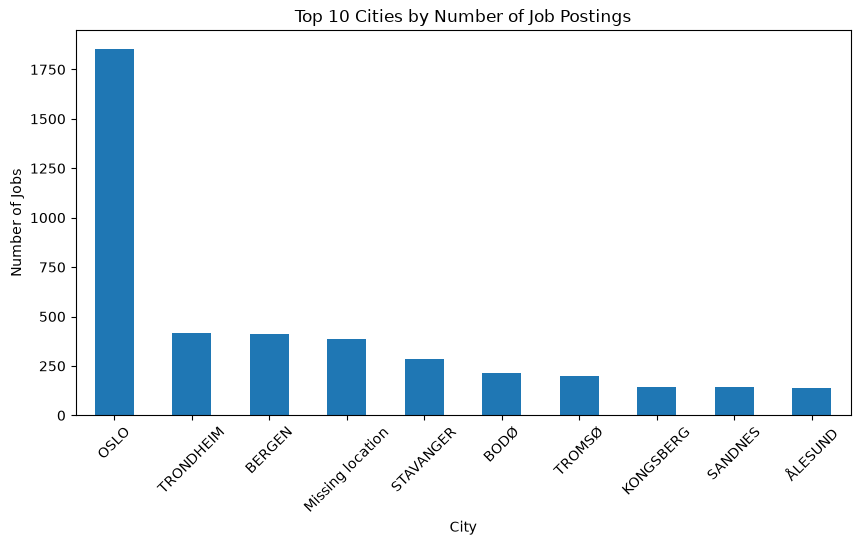

In [16]:
import matplotlib.pyplot as plt

city_counts = df["city"].value_counts().head(10)

plt.figure(figsize=(10,5))
city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Job Postings")
plt.xlabel("City")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.show()

### Key Findings - Job Distribution by City

- Oslo has by far the highest number of job postings, showing a strong concentration of employment opportunities in the capital region.
- Other major employment hubs include Trondheim, Bergen, Stavanger, Bodø, and Tromsø.
- A noticeable number of job postings have missing location information, indicating incomplete metadata in the source data.
- Missing location records are kept in the dataset to avoid introducing bias by removing incomplete observations.

In [17]:
# Save this result for later Power BI/dashboard use
city_analysis = df["city"].value_counts().reset_index()

city_analysis.columns = ["city", "job_count"]

city_analysis.to_csv(
    "../data/processed/city_job_distribution.csv",
    index=False
)

In [24]:
# helper columns
# How much occupation data exists
df["occupation_available"] = (
    df["occupation"] != "Not classified"
)
df["occupation_available"].value_counts()



occupation_available
False    8104
True     1896
Name: count, dtype: int64

In [25]:
occupation_df = df[df["occupation_available"]]

occupation_df["occupation"].value_counts().head(15)

occupation
,               1469
, ,              315
, , ,             78
, , , ,           22
, , , , ,         10
, , , , , ,        2
Name: count, dtype: int64

### Occupation data limitation

The occupation field has significant missing classification.
Only a subset of job postings contains NAV occupation mapping.
Missing values are treated as missing metadata rather than removed,
because they may represent valid jobs without occupation classification.

Occupation data is incomplete. Only 19% of job postings contain NAV occupation classification.
This field will be used only for supplementary analysis.

The occupation field was investigated but excluded from analysis because the NAV occupation mapping was incomplete and extraction did not produce reliable occupation labels. Only 19% of records contained occupation information, and the available values were not sufficiently structured for analysis.

## Exploding the skills column

In [36]:
skills_df = df[["job_id", "skills"]].copy()

skills_df["skill"] = skills_df["skills"].str.split(",")

skills_df = skills_df.explode("skill")

skills_df["skill"] = skills_df["skill"].str.strip()


skills_df.head()



,job_id,skills,skill
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning


In [27]:
skills_df["skill"].value_counts().head(20)

skill
Omsorg                   1471
Kundeservice             1396
Helse                    1106
Butikk                   1057
Salg                      981
Leder                     895
Service                   839
Kontor                    808
Sykepleier                716
Kasse                     636
Butikkmedarbeider         632
Personalansvar            618
Administrasjon            571
Sykehus                   565
Assistent                 543
Veiledning                533
Barn                      519
Tverrfaglig samarbeid     476
Ledelse                   475
Rådgiver                  472
Name: count, dtype: int64

In [28]:
(skills_df["skill"] == "").sum()

np.int64(0)

What skills are most demanded in the Norwegian job market?

In [29]:
# creating frequency table
skill_demand = (
    skills_df["skill"]
    .value_counts()
    .reset_index()
)

skill_demand.columns = ["skill", "job_count"]

skill_demand.head(20)

,skill,job_count
0,Omsorg,1471
1,Kundeservice,1396
2,Helse,1106
3,Butikk,1057
4,Salg,981
5,Leder,895
6,Service,839
7,Kontor,808
8,Sykepleier,716
9,Kasse,636


Next step: we need to understand how many skills each job requires.

In [30]:
job_skill_count = (
    skills_df.groupby("job_id")
    .size()
    .reset_index(name="number_of_skills")
)

job_skill_count.head()

,job_id,number_of_skills
0,0008dd66-d1c7-41ae-a911-1d6d0b84e092,10
1,001773d0-923c-4001-bea7-bb53098f5ba6,8
2,001903b6-c738-42b0-b70c-a9d13d1cbc85,10
3,001e12b0-b264-4fc6-9bb7-c9b42ff6dcf4,6
4,0028b108-259b-4554-8439-55bdc19f374e,10


In [31]:
job_skill_count["number_of_skills"].describe()

count    10000.000000
mean         9.532400
std          0.806979
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         13.000000
Name: number_of_skills, dtype: float64

In [32]:
skills_df["skill"].nunique()

10997

In [33]:
skills_df["skill"].value_counts().tail(10)

skill
Datateknikk          1
Medisinsk teknisk    1
Medisintekniker      1
Relévern             1
Dataoverføring       1
Telemetri            1
Elkontroll           1
Chief Engineer       1
Kommisjonering       1
Skipsdrift           1
Name: count, dtype: int64

In [34]:
# main skill landscape
skills_df["skill"].value_counts().head(50)

skill
Omsorg                   1471
Kundeservice             1396
Helse                    1106
Butikk                   1057
Salg                      981
Leder                     895
Service                   839
Kontor                    808
Sykepleier                716
Kasse                     636
Butikkmedarbeider         632
Personalansvar            618
Administrasjon            571
Sykehus                   565
Assistent                 543
Veiledning                533
Barn                      519
Tverrfaglig samarbeid     476
Ledelse                   475
Rådgiver                  472
Vedlikehold               471
Teamarbeid                470
Barnehage                 469
Prosjektledelse           446
Helsefagarbeider          441
Industri                  433
Pleie                     411
HMS                       402
Kundebehandling           402
Renhold                   382
Pasientbehandling         381
Bygg                      377
Vernepleier               368
Anal

In [37]:
skills_df.to_csv(
    "../data/processed/job_skills.csv",
    index=False
)
